In [1]:
import cv2 as cv
import numpy as numpy
import matplotlib.pyplot as plt

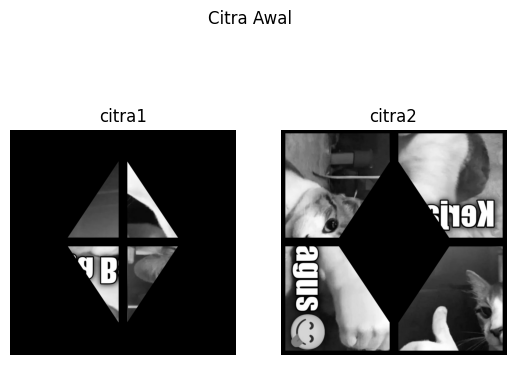

In [2]:
gbr1=cv.imread("Assets/citra1.PNG")
gbr2=cv.imread("Assets/citra2.PNG")

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(gbr1, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title("citra1")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(gbr2, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title("citra2")

plt.suptitle("Citra Awal")
plt.show()

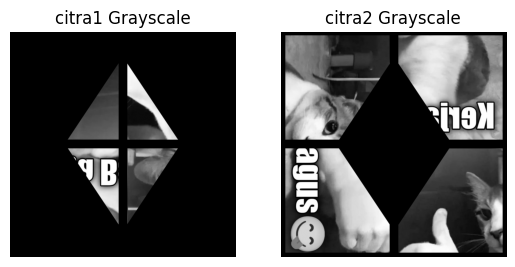

In [3]:
gbr1_gray = cv.cvtColor(gbr1, cv.COLOR_BGR2GRAY)
gbr2_gray = cv.cvtColor(gbr2, cv.COLOR_BGR2GRAY)

plt.subplot(1,2,1)
plt.imshow(gbr1_gray, cmap='gray')
plt.axis('off')
plt.title("citra1 Grayscale")

plt.subplot(1,2,2)
plt.imshow(gbr2_gray, cmap='gray')
plt.axis('off')
plt.title("citra2 Grayscale")

plt.show()

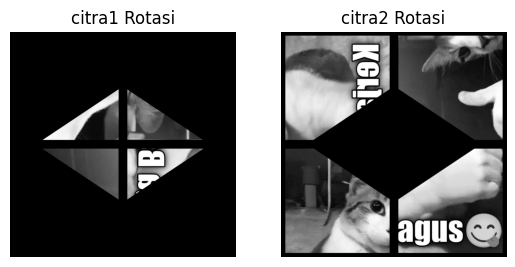

In [4]:
def rotate_image(image, angle):
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    M = cv.getRotationMatrix2D(center, angle, 1.0)
    return cv.warpAffine(image, M, (width, height))

gbr1_rot = rotate_image(gbr1_gray, 90)
gbr2_rot = rotate_image(gbr2_gray, 90)

plt.subplot(1,2,1)
plt.imshow(gbr1_rot, cmap='gray')
plt.axis('off')
plt.title("citra1 Rotasi")

plt.subplot(1,2,2)
plt.imshow(gbr2_rot, cmap='gray')
plt.axis('off')
plt.title("citra2 Rotasi")

plt.show()

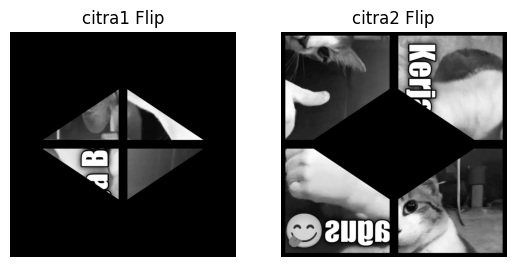

In [5]:
gbr1_flip = cv.flip(gbr1_rot, 1)
gbr2_flip = cv.flip(gbr2_rot, 1)

plt.subplot(1,2,1)
plt.imshow(gbr1_flip, cmap='gray')
plt.axis('off')
plt.title("citra1 Flip")

plt.subplot(1,2,2)
plt.imshow(gbr2_flip, cmap='gray')
plt.axis('off')
plt.title("citra2 Flip")

plt.show()

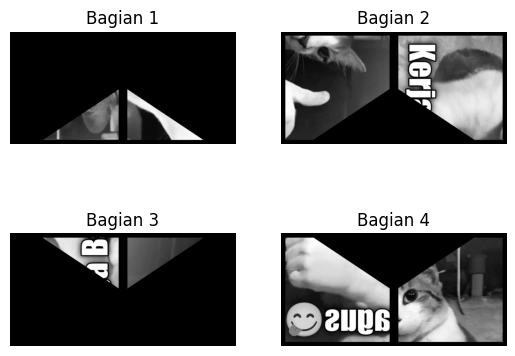

In [6]:
# Gabung dulu
gabung = cv.hconcat([gbr1_flip, gbr2_flip])

# Split jadi 4
h, w = gabung.shape
h2, w2 = h//2, w//2

c1 = gabung[0:h2, 0:w2]
c2 = gabung[0:h2, w2:w]
c3 = gabung[h2:h, 0:w2]
c4 = gabung[h2:h, w2:w]

# Tampilkan 4 bagian
plt.subplot(2,2,1)
plt.imshow(c1, cmap='gray')
plt.axis('off')
plt.title("Bagian 1")

plt.subplot(2,2,2)
plt.imshow(c2, cmap='gray')
plt.axis('off')
plt.title("Bagian 2")

plt.subplot(2,2,3)
plt.imshow(c3, cmap='gray')
plt.axis('off')
plt.title("Bagian 3")

plt.subplot(2,2,4)
plt.imshow(c4, cmap='gray')
plt.axis('off')
plt.title("Bagian 4")

plt.show()

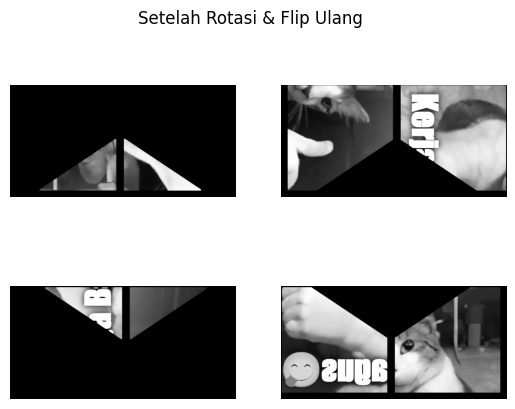

In [19]:
c1 = numpy.rot90(c1)
c2 = numpy.rot90(c2)
c3 = numpy.rot90(c3)
c4 = numpy.rot90(c4)

c1 = numpy.fliplr(c1)
c2 = numpy.flipud(c2)
c3 = numpy.fliplr(c3)
c4 = numpy.flipud(c4)

plt.subplot(2,2,1)
plt.imshow(c1, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(c2, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(c3, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(c4, cmap='gray')
plt.axis('off')

plt.suptitle("Setelah Rotasi & Flip Ulang")
plt.show()

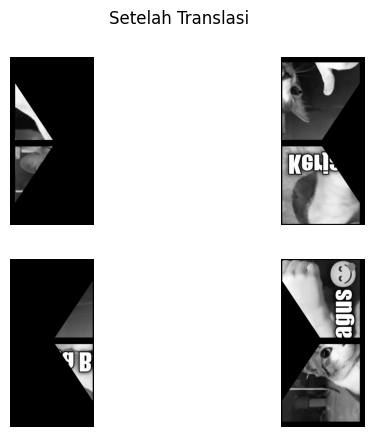

In [8]:
def translasi(img, tx, ty):
    h, w = img.shape
    result = numpy.zeros_like(img)
    for i in range(h):
        for j in range(w):
            if 0 <= i+ty < h and 0 <= j+tx < w:
                result[i+ty][j+tx] = img[i][j]
    return result

c1 = translasi(c1, 10, 10)
c2 = translasi(c2, -10, 10)
c3 = translasi(c3, 10, -10)
c4 = translasi(c4, -10, -10)

plt.subplot(2,2,1)
plt.imshow(c1, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(c2, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(c3, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(c4, cmap='gray')
plt.axis('off')

plt.suptitle("Setelah Translasi")
plt.show()

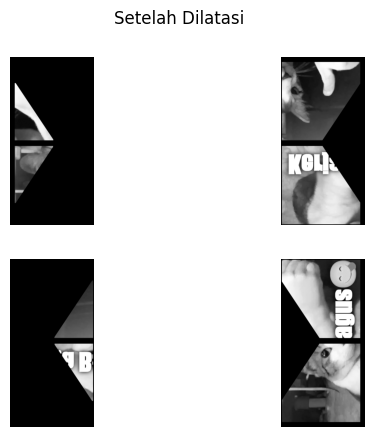

In [17]:
kernel = numpy.ones((3,3), numpy.uint8)

c1 = cv.dilate(c1, kernel, iterations=1)
c2 = cv.dilate(c2, kernel, iterations=1)
c3 = cv.dilate(c3, kernel, iterations=1)
c4 = cv.dilate(c4, kernel, iterations=1)

plt.subplot(2,2,1)
plt.imshow(c1, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(c2, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(c3, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(c4, cmap='gray')
plt.axis('off')

plt.suptitle("Setelah Dilatasi")
plt.show()

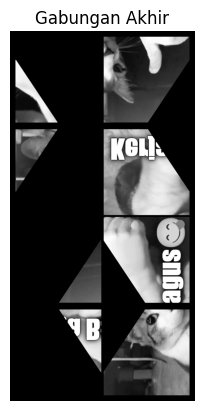

In [10]:
atas = cv.hconcat([c1, c2])
bawah = cv.hconcat([c3, c4])
final = cv.vconcat([atas, bawah])
final = final // 2

plt.imshow(final, cmap='gray')
plt.axis('off')
plt.title("Gabungan Akhir")
plt.show()

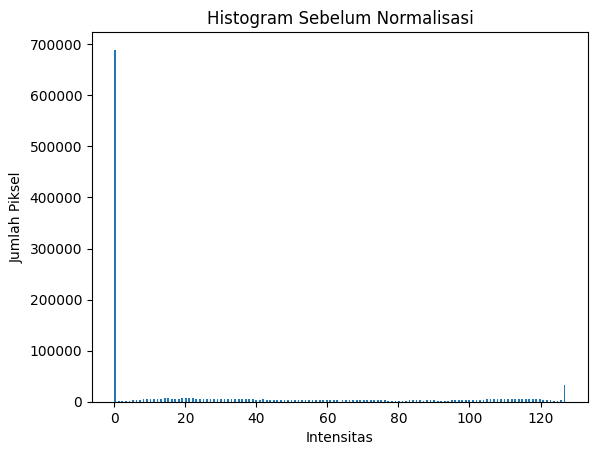

In [11]:
plt.hist(final.ravel(), bins=256)
plt.title("Histogram Sebelum Normalisasi")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")
plt.show()

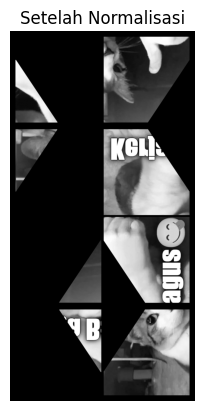

In [12]:
norm = cv.normalize(final, None, 0, 255, cv.NORM_MINMAX, dtype=cv.CV_8U)

plt.imshow(norm, cmap='gray')
plt.axis('off')
plt.title("Setelah Normalisasi")
plt.show()

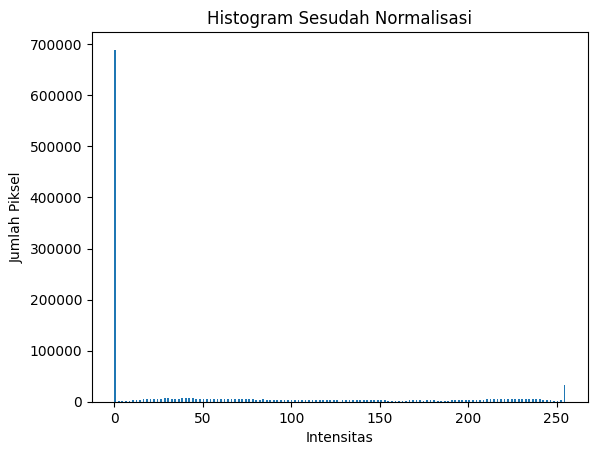

In [13]:
plt.hist(norm.ravel(), bins=256)
plt.title("Histogram Sesudah Normalisasi")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")
plt.show()

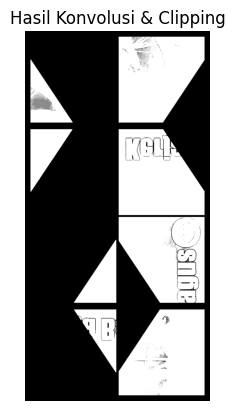

In [14]:
kernel_conv = numpy.array([
    [-1, -1, 0, -1, -1],
    [-1, 0, 4, 0, -1],
    [0, 4, 10, 4, 0],
    [-1, 0, 4, 0, -1],
    [-1, -1, 0, -1, -1]
], dtype=numpy.float32)

conv = cv.filter2D(norm, -1, kernel_conv, borderType=cv.BORDER_CONSTANT)

# Clipping
conv = numpy.clip(conv, 0, 255).astype(numpy.uint8)

plt.imshow(conv, cmap='gray')
plt.axis('off')
plt.title("Hasil Konvolusi & Clipping")
plt.show()

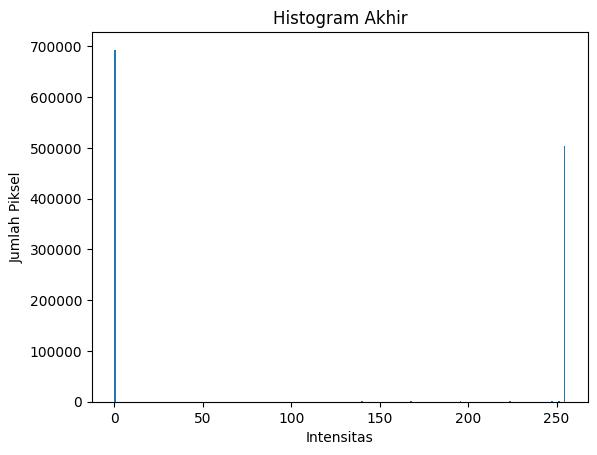

In [15]:
plt.hist(conv.ravel(), bins=256)
plt.title("Histogram Akhir")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")
plt.show()

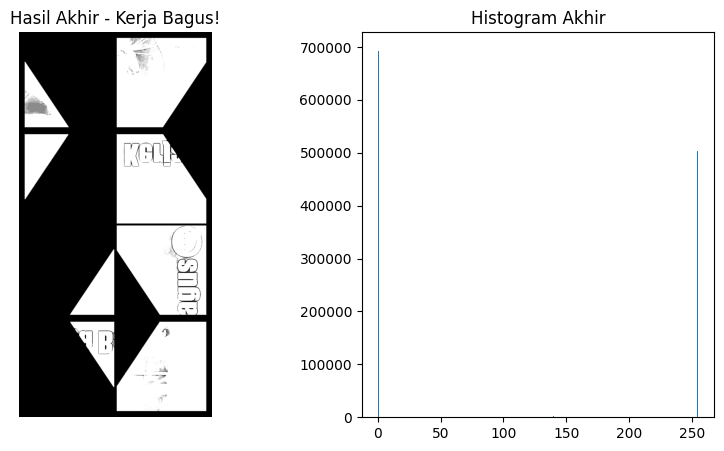

Selesai!


In [16]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(conv, cmap='gray')
plt.axis('off')
plt.title("Hasil Akhir - Kerja Bagus!")

plt.subplot(1,2,2)
plt.hist(conv.ravel(), bins=256)
plt.title("Histogram Akhir")

plt.show()

print("Selesai!")

Analisis proses
 
pada percobaan ini, dilakukan serangkaian proses perbaikan citra yang dimulai denngan memuat dua gambar awal, kemudian mengubahnya menjadi skala abu-abu (grayscale) agar lebih mudah diolah. selanjutnya dilakukan rotasi manual dan pembalikan arah (flipping) untuk memperbaiki posisi gambar, lalu kedua gambar digabungkan dan dipotong menjadi empat bagian. Setiap bagian tersebut disusun kembali dengan teknik translasi agar posisinya rapi, kemudian dipertebal menggunakan operasi morfologi dilatasi agar detail lebih jelas. Setelah digabungkan kembali menjadi satu gambar utuh, dilakukan peningkatan kualitas melalui normalisasi agar kontras dan kecerahannya menjadi lebih baik, dilanjutkan dengan proses filtering menggunakan metode konvolusi dan zero padding untuk menajamkan tepi objek. Terakhir, dilakukan pembatasan nilai piksel (clipping) dan analisis melalui histogram yang menunjukkan perubahan distribusi intensitas, sehingga dihasilkan citra akhir yang utuh, jelas, dan siap digunakan